<a href="https://colab.research.google.com/github/Zdravko27/ai-lipik/blob/main/zavr%C5%A1ni_rad_rije%C5%A1eno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. INSTALL DEPENDENCIES
# ==========================================
!apt-get update -qq
!apt-get install -y -qq poppler-utils tesseract-ocr
!pip install -q pytesseract pdf2image rapidfuzz opencv-python

import os
import re
import zipfile
import pandas as pd
import pytesseract
from PIL import Image
from pdf2image import convert_from_bytes
from rapidfuzz import fuzz
from datetime import datetime
from io import BytesIO
from collections import Counter, defaultdict
import numpy as np

# ==========================================
# 2. CONFIG – DATASET PATH
# ==========================================

DATASET_ZIP = "/content/large-receipt-image-dataset-SRD.zip"

if not os.path.exists(DATASET_ZIP):
    raise FileNotFoundError(f"Dataset not found at {DATASET_ZIP}")

# ==========================================
# 3. GLOBAL STRUCTURES (AUTO-LEARNING)
# ==========================================

AUTO_STORE_WORDS = Counter()
AUTO_ITEM_WORDS = Counter()
AUTO_BLACKLIST = Counter()

STORE_KEYWORDS = {}
CATEGORIES = {}
BLACKLIST = []
LEARNED_WORDS = {}

# ==========================================
# 4. HELPER FUNKCIJE – DETEKCIJE
# ==========================================

def detect_currency(text):
    tl = text.lower()
    if "usd" in tl or "$" in text:
        return "USD"
    if "gbp" in tl or "£" in text:
        return "GBP"
    if "eur" in tl or "€" in text:
        return "EUR"
    if "hrk" in tl or "kn" in tl:
        return "HRK"
    return "Unknown"

def detect_date(text):
    patterns = [
        r"\d{2}[./-]\d{2}[./-]\d{4}",
        r"\d{4}[./-]\d{2}[./-]\d{2}",
        r"\d{2}[./-]\d{2}[./-]\d{2}"
    ]
    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)
    return None

# ==========================================
# 5. AUTO-LEARNING HELPERI
# ==========================================

def extract_header_words(text, max_lines=10):
    lines = text.split("\n")[:max_lines]
    words = []
    for l in lines:
        # uppercase blokovi, često naziv trgovine
        for w in re.findall(r"[A-ZČĆŽŠĐ][A-Z0-9ČĆŽŠĐ\-]{2,}", l):
            words.append(w.lower())
    return words

def extract_item_words(text):
    words = []
    for line in text.split("\n"):
        if re.search(r"\d+[\.,]\d{2}", line):
            name = re.sub(r"[^a-zA-ZčćžšđČĆŽŠĐ ]", " ", line).lower()
            for w in name.split():
                if len(w) > 2:
                    words.append(w)
    return words

def extract_blacklist_words(text):
    words = []
    for line in text.split("\n"):
        if re.search(r"\d+[\.,]\d{2}", line):
            for w in re.findall(r"[a-zA-ZčćžšđČĆŽŠĐ]+", line.lower()):
                if w in [
                    "total","ukupno","tax","porez","amount","iznos","change","gotovina",
                    "cash","visa","master","card","subtotal","balance","kartica",
                    "račun","racun","br","broj","fiskal","povrat","povratak"
                ]:
                    words.append(w)
    return words

# ==========================================
# 6. PASS 1 – SAMO UČENJE IZ DATASETA
# ==========================================

def ocr_from_zip_member(z, fname):
    data = z.read(fname)
    if fname.lower().endswith(".pdf"):
        pages = convert_from_bytes(data)
        text = "".join([pytesseract.image_to_string(p, lang="eng") for p in pages])
    else:
        img = Image.open(BytesIO(data))
        text = pytesseract.image_to_string(img, lang="eng")
    return text

print("🔍 PASS 1 – učenje iz dataset-a...")

with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
    all_names = [n for n in z.namelist() if n.lower().endswith(('.png','.jpg','.jpeg','.pdf'))]
    print(f"Pronađeno {len(all_names)} datoteka.")

    for idx, fname in enumerate(all_names, start=1):
        try:
            text = ocr_from_zip_member(z, fname)
        except Exception:
            continue

        if not text.strip():
            continue

        AUTO_STORE_WORDS.update(extract_header_words(text))
        AUTO_ITEM_WORDS.update(extract_item_words(text))
        AUTO_BLACKLIST.update(extract_blacklist_words(text))

print("PASS 1 gotovo.")

# ==========================================
# 7. GENERIRANJE STORE_KEYWORDS, CATEGORIES, BLACKLIST, LEARNED_WORDS
# ==========================================

# --- STORE_KEYWORDS ---
top_stores = [w for w, c in AUTO_STORE_WORDS.most_common(30)]
STORE_KEYWORDS = {s.upper(): [s] for s in top_stores}
STORE_KEYWORDS["Unknown"] = []

def detect_store(text):
    t = text.lower()
    for store, keys in STORE_KEYWORDS.items():
        for k in keys:
            if k in t:
                return store
    return "Unknown"

# --- CATEGORIES (seed + auto) ---
common_words = [w for w, c in AUTO_ITEM_WORDS.most_common(400)]

seed_categories = {
    "Drinks": ["cola","coke","pepsi","voda","water","juice","sok","beer","pivo","wine","vino","milk","mlijeko","tea","kava","coffee"],
    "Food": ["bread","kruh","meat","meso","chicken","piletina","rice","riža","pasta","tjestenina","egg","jaje","cheese","sir","ham","šunka","yogurt","jogurt"],
    "Fruits & Vegetables": ["apple","banana","lemon","onion","luk","tomato","rajčica","potato","krumpir","carrot","mrkva","salad","salata"],
    "Hygiene & Household": ["soap","sapun","shampoo","šampon","detergent","deterdžent","towel","ručnik","paper","papir","vrećica","vrecica"],
    "Sweets": ["chocolate","čokolada","candy","bombon","snack","grickalice","cookie","keks","wafer","napolitanka"]
}

CATEGORIES = {cat: [] for cat in seed_categories.keys()}

for w in common_words:
    for cat, seeds in seed_categories.items():
        if any(fuzz.partial_ratio(w, s) > 80 for s in seeds):
            CATEGORIES[cat].append(w)
            break

# --- BLACKLIST ---
BLACKLIST = list(set(
    [
        "tax","total","amount","change","cash","visa","master","card","subtotal",
        "balance","ukupno","iznos","gotovina","kartica","račun","racun","porez",
        "fiskal","povrat","br","broj"
    ]
    + [w for w, c in AUTO_BLACKLIST.items() if c > 5]
))

# --- LEARNED_WORDS ---
LEARNED_WORDS = {cat: set(words) for cat, words in CATEGORIES.items()}
LEARNED_WORDS["Other"] = set()

# ==========================================
# 8. KATEGORIZACIJA ARTIKALA
# ==========================================

def categorize_item(name):
    text = name.lower().strip()
    if any(b in text for b in BLACKLIST):
        return "FILTERED"

    clean = re.sub(r'[^a-zA-ZčćžšđČĆŽŠĐ]', ' ', text)

    best_cat = "Other"
    best_score = 0

    for category, words in LEARNED_WORDS.items():
        for w in words:
            score = fuzz.partial_ratio(clean, w)
            if score > best_score:
                best_score = score
                best_cat = category

    if best_score < 60 and len(clean) > 3:
        LEARNED_WORDS["Other"].add(clean)

    return best_cat

# ==========================================
# 9. PASS 2 – PRAVA OBRADA + CSV
# ==========================================

print("📦 PASS 2 – obrada i izvoz u CSV...")

results = []

with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
    all_names = [n for n in z.namelist() if n.lower().endswith(('.png','.jpg','.jpeg','.pdf'))]

    for idx, fname in enumerate(all_names, start=1):
        print(f"[{idx}/{len(all_names)}] {fname}")

        try:
            text = ocr_from_zip_member(z, fname)
        except Exception:
            continue

        if not text.strip():
            continue

        store = detect_store(text)
        currency = detect_currency(text)
        date = detect_date(text)

        for line in text.split("\n"):
            line = line.strip()
            if not line:
                continue

            match = re.search(r"(\d+[\.,]\d{2})", line)
            if not match:
                continue

            price_str = match.group(1)
            try:
                price = float(price_str.replace(",", "."))
            except:
                continue

            item_name = line.split(price_str)[0].strip()
            if len(item_name) < 2:
                continue

            category = categorize_item(item_name)

            if category != "FILTERED":
                results.append({
                    "File": fname,
                    "Store": store,
                    "Date": date,
                    "Currency": currency,
                    "Category": category,
                    "Original_Item": item_name,
                    "Price": price
                })

# ==========================================
# 10. ČIŠĆENJE I IZVOZ
# ==========================================

df = pd.DataFrame(results)

df = df[df["Currency"] != "Unknown"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Date"] = df["Date"].fillna(datetime.now())

df = df.dropna(subset=["Price"])

print("Final cleaned DataFrame:")
display(df.head())
print("Shape:", df.shape)

out_path = "/content/Expense_Analysis_Final_SRD.csv"
df.to_csv(out_path, index=False)
print(f"\n✅ CSV file saved as {out_path}")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.4 MB/s eta 0:00:00
🔍 PASS 1 – učenje iz dataset-a...
Pronađeno 200 datoteka.
PASS 1 gotovo.
📦 PASS 2 – obrada i izvoz u CSV...
[1/200] 1078-receipt.jpg
[2/200] 1085-receipt.jpg
[3/200] 1197-receipt.jpg
[4/200] 1008-receipt.jpg
[5/200] 1134-receipt.jpg
[6/200] 1056-receipt.jpg
[7/200] 1144-receipt.jpg
[8/200] 1026-receipt.jpg
[9/200] 1158-receipt.jpg
[10/200] 1128-receipt.jpg
[11/200] 1176-receipt.jpg
[1

/tmp/ipykernel_3116/3735639417.py:284: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,File,Store,Date,Currency,Category,Original_Item,Price
0,1078-receipt.jpg,ORDER,2026-04-23 16:35:31.336629,USD,Fruits & Vegetables,00% of sale: $,2.33
1,1078-receipt.jpg,ORDER,2026-04-23 16:35:31.336629,USD,Drinks,Ie; $,2.59
3,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Other,2x,0.50
4,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Other,2x,5.00
5,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Drinks,Hacedon ia,10.00


Shape: (271, 7)

✅ CSV file saved as /content/Expense_Analysis_Final_SRD.csv


In [ ]:
# ==========================================
# 1. INSTALL DEPENDENCIES
# ==========================================
!apt-get update -qq
!apt-get install -y -qq poppler-utils tesseract-ocr
!pip install -q pytesseract pdf2image rapidfuzz opencv-python

import os
import re
import zipfile
import pandas as pd
import pytesseract
from PIL import Image
from pdf2image import convert_from_bytes
from rapidfuzz import fuzz
from datetime import datetime
from io import BytesIO
from collections import Counter, defaultdict
import numpy as np

# ==========================================
# 2. CONFIG – DATASET PATH
# ==========================================

DATASET_ZIP = "/content/large-receipt-image-dataset-SRD.zip"

if not os.path.exists(DATASET_ZIP):
    raise FileNotFoundError(f"Dataset not found at {DATASET_ZIP}")

# ==========================================
# 3. GLOBAL STRUCTURES (AUTO-LEARNING)
# ==========================================

AUTO_STORE_WORDS = Counter()
AUTO_ITEM_WORDS = Counter()
AUTO_BLACKLIST = Counter()

STORE_KEYWORDS = {}
CATEGORIES = {}
BLACKLIST = []
LEARNED_WORDS = {}

# ==========================================
# 4. HELPER FUNKCIJE – DETEKCIJE
# ==========================================

def detect_currency(text):
    tl = text.lower()
    if "usd" in tl or "$" in text:
        return "USD"
    if "gbp" in tl or "£" in text:
        return "GBP"
    if "eur" in tl or "€" in text:
        return "EUR"
    if "hrk" in tl or "kn" in tl:
        return "HRK"
    return "Unknown"

def detect_date(text):
    patterns = [
        r"\d{2}[./-]\d{2}[./-]\d{4}",
        r"\d{4}[./-]\d{2}[./-]\d{2}",
        r"\d{2}[./-]\d{2}[./-]\d{2}"
    ]
    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)
    return None

# ==========================================
# 5. AUTO-LEARNING HELPERI
# ==========================================

def extract_header_words(text, max_lines=10):
    lines = text.split("\n")[:max_lines]
    words = []
    for l in lines:
        # uppercase blokovi, često naziv trgovine
        for w in re.findall(r"[A-ZČĆŽŠĐ][A-Z0-9ČĆŽŠĐ\-]{2,}", l):
            words.append(w.lower())
    return words

def extract_item_words(text):
    words = []
    for line in text.split("\n"):
        if re.search(r"\d+[\.,]\d{2}", line):
            name = re.sub(r"[^a-zA-ZčćžšđČĆŽŠĐ ]", " ", line).lower()
            for w in name.split():
                if len(w) > 2:
                    words.append(w)
    return words

def extract_blacklist_words(text):
    words = []
    for line in text.split("\n"):
        if re.search(r"\d+[\.,]\d{2}", line):
            for w in re.findall(r"[a-zA-ZčćžšđČĆŽŠĐ]+", line.lower()):
                if w in [
                    "total","ukupno","tax","porez","amount","iznos","change","gotovina",
                    "cash","visa","master","card","subtotal","balance","kartica",
                    "račun","racun","br","broj","fiskal","povrat","povratak"
                ]:
                    words.append(w)
    return words

# ==========================================
# 6. PASS 1 – SAMO UČENJE IZ DATASETA
# ==========================================

def ocr_from_zip_member(z, fname):
    data = z.read(fname)
    if fname.lower().endswith(".pdf"):
        pages = convert_from_bytes(data)
        text = "".join([pytesseract.image_to_string(p, lang="eng") for p in pages])
    else:
        img = Image.open(BytesIO(data))
        text = pytesseract.image_to_string(img, lang="eng")
    return text

print("🔍 PASS 1 – učenje iz dataset-a...")

with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
    all_names = [n for n in z.namelist() if n.lower().endswith(('.png','.jpg','.jpeg','.pdf'))]
    print(f"Pronađeno {len(all_names)} datoteka.")

    for idx, fname in enumerate(all_names, start=1):
        try:
            text = ocr_from_zip_member(z, fname)
        except Exception:
            continue

        if not text.strip():
            continue

        AUTO_STORE_WORDS.update(extract_header_words(text))
        AUTO_ITEM_WORDS.update(extract_item_words(text))
        AUTO_BLACKLIST.update(extract_blacklist_words(text))

print("PASS 1 gotovo.")

# ==========================================
# 7. GENERIRANJE STORE_KEYWORDS, CATEGORIES, BLACKLIST, LEARNED_WORDS
# ==========================================

# --- STORE_KEYWORDS ---
top_stores = [w for w, c in AUTO_STORE_WORDS.most_common(30)]
STORE_KEYWORDS = {s.upper(): [s] for s in top_stores}
STORE_KEYWORDS["Unknown"] = []

# Manually adding/updating specific stores and removing generic ones
STORE_KEYWORDS['TOTAL SUPERMARKET'] = ['total supermarket', 'total market', 'market total']
STORE_KEYWORDS['ORDER ONLINE'] = ['order online', 'online order']
if 'TOTAL' in STORE_KEYWORDS:
    del STORE_KEYWORDS['TOTAL']
if 'ORDER' in STORE_KEYWORDS:
    del STORE_KEYWORDS['ORDER']

def detect_store(text):
    t = text.lower()
    for store, keys in STORE_KEYWORDS.items():
        for k in keys:
            if k in t:
                return store
    return "Unknown"

# --- CATEGORIES (seed + auto) ---
common_words = [w for w, c in AUTO_ITEM_WORDS.most_common(400)]

seed_categories = {
    "Drinks": ["cola","coke","pepsi","voda","water","juice","sok","beer","pivo","wine","vino","milk","mlijeko","tea","kava","coffee"],
    "Food": ["bread","kruh","meat","meso","chicken","piletina","rice","riža","pasta","tjestenina","egg","jaje","cheese","sir","ham","šunka","yogurt","jogurt"],
    "Fruits & Vegetables": ["apple","banana","lemon","onion","luk","tomato","rajčica","potato","krumpir","carrot","mrkva","salad","salata"],
    "Hygiene & Household": ["soap","sapun","shampoo","šampon","detergent","deterdžent","towel","ručnik","paper","papir","vrećica","vrecica"],
    "Sweets": ["chocolate","čokolada","candy","bombon","snack","grickalice","cookie","keks","wafer","napolitanka"]
}

CATEGORIES = {cat: [] for cat in seed_categories.keys()}

for w in common_words:
    for cat, seeds in seed_categories.items():
        if any(fuzz.partial_ratio(w, s) > 80 for s in seeds):
            CATEGORIES[cat].append(w)
            break

# --- BLACKLIST ---
BLACKLIST = list(set(
    [
        "tax","total","amount","change","cash","visa","master","card","subtotal",
        "balance","ukupno","iznos","gotovina","kartica","račun","racun","porez",
        "fiskal","povrat","br","broj"
    ]
    + [w for w, c in AUTO_BLACKLIST.items() if c > 5]
))

# --- LEARNED_WORDS ---
LEARNED_WORDS = {cat: set(words) for cat, words in CATEGORIES.items()}
LEARNED_WORDS["Other"] = set()

# ==========================================
# 8. KATEGORIZACIJA ARTIKALA
# ==========================================

def categorize_item(name):
    text = name.lower().strip()

    # Enhanced filtering for non-item lines
    # 1. Check for lines that are predominantly numbers or very short without meaningful words
    clean_alpha = re.sub(r'[^a-zčćžšđ]', '', text) # only keep alphabetic chars
    if (len(clean_alpha) < 3 and len(text) < 7) or (re.fullmatch(r'[\d\s\.,%]+', text)):
        return "FILTERED"

    # 2. Check for lines containing percentage signs, or common financial terms that aren't already in BLACKLIST
    if '%' in text or \
       (re.search(r'total|subtotal|tax|balance|amount|iznos|ukupno|gotovina|kartica|fiskal|povrat|br|broj|gratuity|due', text) and \
       re.search(r'\d+[\.,]\d{2}', text)):
        return "FILTERED"

    # Original BLACKLIST check
    if any(b in text for b in BLACKLIST):
        return "FILTERED"

    clean = re.sub(r'[^a-zA-ZčćžšđČĆŽŠĐ]', ' ', text)

    best_cat = "Other"
    best_score = 0

    for category, words in LEARNED_WORDS.items():
        for w in words:
            score = fuzz.partial_ratio(clean, w)
            if score > best_score:
                best_score = score
                best_cat = category

    if best_score < 60 and len(clean) > 3:
        LEARNED_WORDS["Other"].add(clean)

    return best_cat

# ==========================================
# 9. PASS 2 – PRAVA OBRADA + CSV
# ==========================================

print("📦 PASS 2 – obrada i izvoz u CSV...")

results = []

with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
    all_names = [n for n in z.namelist() if n.lower().endswith(('.png','.jpg','.jpeg','.pdf'))]

    for idx, fname in enumerate(all_names, start=1):
        print(f"[{idx}/{len(all_names)}] {fname}")

        try:
            text = ocr_from_zip_member(z, fname)
        except Exception:
            continue

        if not text.strip():
            continue

        store = detect_store(text)
        currency = detect_currency(text)
        date = detect_date(text)

        for line in text.split("\n"):
            line = line.strip()
            if not line:
                continue

            match = re.search(r"(\d+[\.,]\d{2})", line)
            if not match:
                continue

            price_str = match.group(1)
            try:
                price = float(price_str.replace(",", "."))
            except:
                continue

            item_name = line.split(price_str)[0].strip()
            if len(item_name) < 2:
                continue

            category = categorize_item(item_name)

            if category != "FILTERED":
                results.append({
                    "File": fname,
                    "Store": store,
                    "Date": date,
                    "Currency": currency,
                    "Category": category,
                    "Original_Item": item_name,
                    "Price": price
                })

# ==========================================
# 10. ČIŠĆENJE I IZVOZ
# ==========================================

df = pd.DataFrame(results)

df = df[df["Currency"] != "Unknown"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Date"] = df["Date"].fillna(datetime.now())

df = df.dropna(subset=["Price"])

print("Final cleaned DataFrame:")
display(df.head())
print("Shape:", df.shape)

out_path = "/content/Expense_Analysis_Final_SRD.csv"
df.to_csv(out_path, index=False)
print(f"\n✅ CSV file saved as {out_path}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
🔍 PASS 1 – učenje iz dataset-a...
Pronađeno 200 datoteka.
PASS 1 gotovo.
📦 PASS 2 – obrada i izvoz u CSV...
[1/200] 1078-receipt.jpg
[2/200] 1085-receipt.jpg
[3/200] 1197-receipt.jpg
[4/200] 1008-receipt.jpg
[5/200] 1134-receipt.jpg
[6/200] 1056-receipt.jpg
[7/200] 1144-receipt.jpg
[8/200] 1026-receipt.jpg
[9/200] 1158-receipt.jpg
[10/200] 1128-receipt.jpg
[11/200] 1176-receipt.jpg
[12/200] 1014-receipt.jpg
[13/200] 1099-receipt.jpg
[14/200] 1106-receipt.jpg
[15/200] 1064-receipt.jpg
[16/200] 1163-receipt.jpg
[17/200] 1001-receipt.jpg
[18/200] 1113-receipt.jpg
[19/200] 1071-receipt.jpg
[20/200] 1121-receipt.jpg
[21/200] 1043-receipt.jpg
[22/200] 1151-receipt.jpg
[23/200] 1033-receipt.jpg
[24/200] 1090-receipt.jpg
[25/200] 1182-receipt.jpg
[26/200] 1138-receipt.jpg
[27/200] 1148-receipt.jpg
[28/200] 1

/tmp/ipykernel_3116/137343921.py:306: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,File,Store,Date,Currency,Category,Original_Item,Price
1,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Drinks,Hacedon ia,10.00
2,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Fruits & Vegetables,Bufala,8.00
3,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Fruits & Vegetables,Pomodor ini,4.00
4,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Fruits & Vegetables,Nat 1/2 It,1.00
5,1008-receipt.jpg,RESTAURANT,2026-04-23 17:25:51.869060,USD,Food,3 Pupusa Queso $,6.75


Shape: (221, 7)

✅ CSV file saved as /content/Expense_Analysis_Final_SRD.csv


In [ ]:
print("Najčešće trgovine u stupcu 'Store' nakon ponovne obrade:")
display(df['Store'].value_counts())

Najčešće trgovine u stupcu 'Store' nakon ponovne obrade:


,count
Store,
TABLE,53
RESTAURANT,44
AVE,40
Unknown,25
BLVD,14
YOUR,13
BAR,11
GUEST,7
BURGER,6


In [ ]:
print("Najčešće trgovine u stupcu 'Store' nakon ponovne obrade:")
display(df['Store'].value_counts())

Najčešće trgovine u stupcu 'Store' nakon ponovne obrade:


,count
Store,
ORDER,67
TABLE,39
TOTAL,36
AVE,29
RESTAURANT,25
BLVD,9
TEL,5
YOUR,5
BAR,4


/tmp/ipykernel_3116/2070410874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_expenses.index, y=category_expenses.values, palette='viridis')


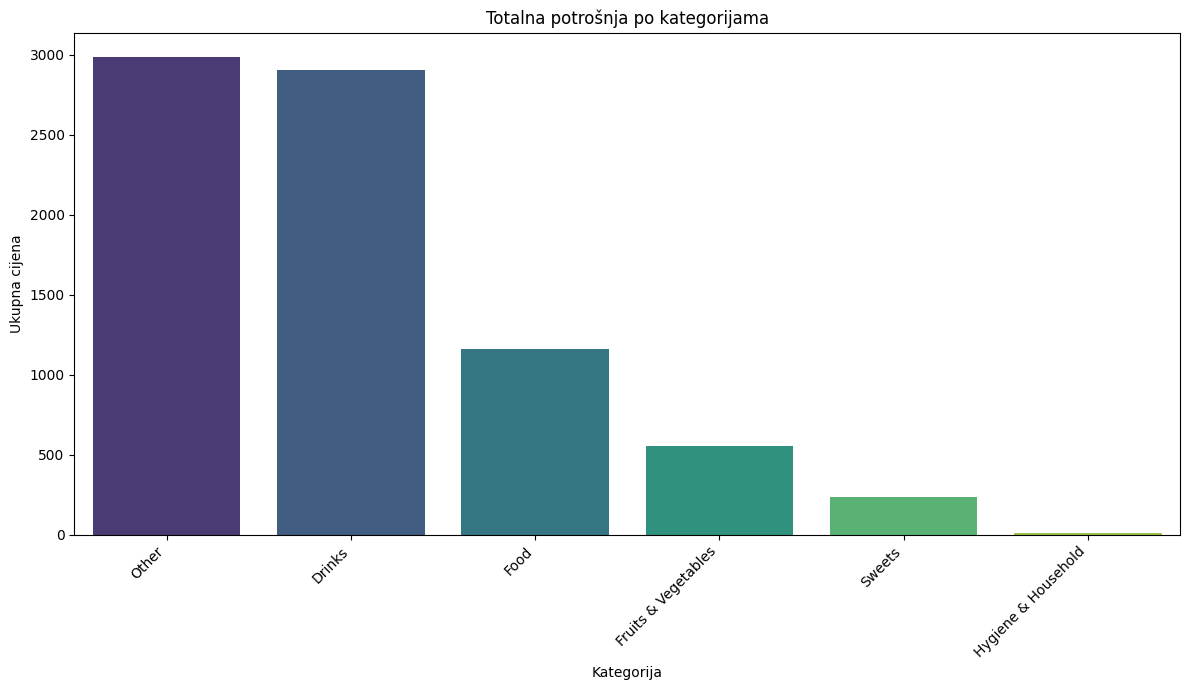

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_expenses = df.groupby('Category')['Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=category_expenses.index, y=category_expenses.values, palette='viridis')
plt.title('Totalna potrošnja po kategorijama')
plt.xlabel('Kategorija')
plt.ylabel('Ukupna cijena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Deskriptivne statistike za sve stupce
print("Deskriptivne statistike:")
display(df.describe(include='all'))

Deskriptivne statistike:


,File,Store,Date,Currency,Category,Original_Item,Price
count,271,271,271,271,271,271,271.000000
unique,65,11,NaN,4,6,261,NaN
top,1162-receipt.jpg,ORDER,NaN,USD,Drinks,Classic Michelada $,NaN
freq,11,79,NaN,254,86,3,NaN
mean,NaN,NaN,2026-02-20 19:03:31.085633536,NaN,NaN,NaN,28.984502
min,NaN,NaN,2018-08-28 00:00:00,NaN,NaN,NaN,0.000000
25%,NaN,NaN,2026-04-23 16:35:31.336628992,NaN,NaN,NaN,3.375000
50%,NaN,NaN,2026-04-23 16:35:31.336628992,NaN,NaN,NaN,7.950000
75%,NaN,NaN,2026-04-23 16:35:31.336628992,NaN,NaN,NaN,13.250000
max,NaN,NaN,2026-04-23 16:35:31.336629,NaN,NaN,NaN,973.770000


In [ ]:
# Provjera nedostajućih vrijednosti
print("\nBroj nedostajućih vrijednosti po stupcima:")
display(df.isnull().sum())


Broj nedostajućih vrijednosti po stupcima:


,0
File,0
Store,0
Date,0
Currency,0
Category,0
Original_Item,0
Price,0


In [ ]:
print("\nAnaliza stavki u kategoriji 'Other':")
other_category_items = df[df['Category'] == 'Other']

# Top 10 stavki po broju pojavljivanja u kategoriji 'Other'
print("\nTop 10 stavki po broju pojavljivanja u kategoriji 'Other':")
display(other_category_items['Original_Item'].value_counts().head(10))

# Top 10 stavki po ukupnoj potrošnji u kategoriji 'Other'
print("\nTop 10 stavki po ukupnoj potrošnji u kategoriji 'Other':")
display(other_category_items.groupby('Original_Item')['Price'].sum().sort_values(ascending=False).head(10))


Analiza stavki u kategoriji 'Other':

Top 10 stavki po broju pojavljivanja u kategoriji 'Other':


,count
Original_Item,
($,3
15% = $,2
2x,2
Med $,2
4 HALIBUT,2
: $,2
18% = $,2
20%: $,1
18%: $,1



Top 10 stavki po ukupnoj potrošnji u kategoriji 'Other':


,Price
Original_Item,
20% =,933.40
r (2,620.00
Ts Fax :,516.77
1 PARTY PK 18-22,139.00
bt $,117.75
4 HALIBUT,76.00
Amt Due: $,55.39
] 06/02 2:449T OT AL 2,39.18
*DRV THRU,34.21


/tmp/ipykernel_3116/1507039126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_expenses.index, y=category_expenses.values, palette='viridis')


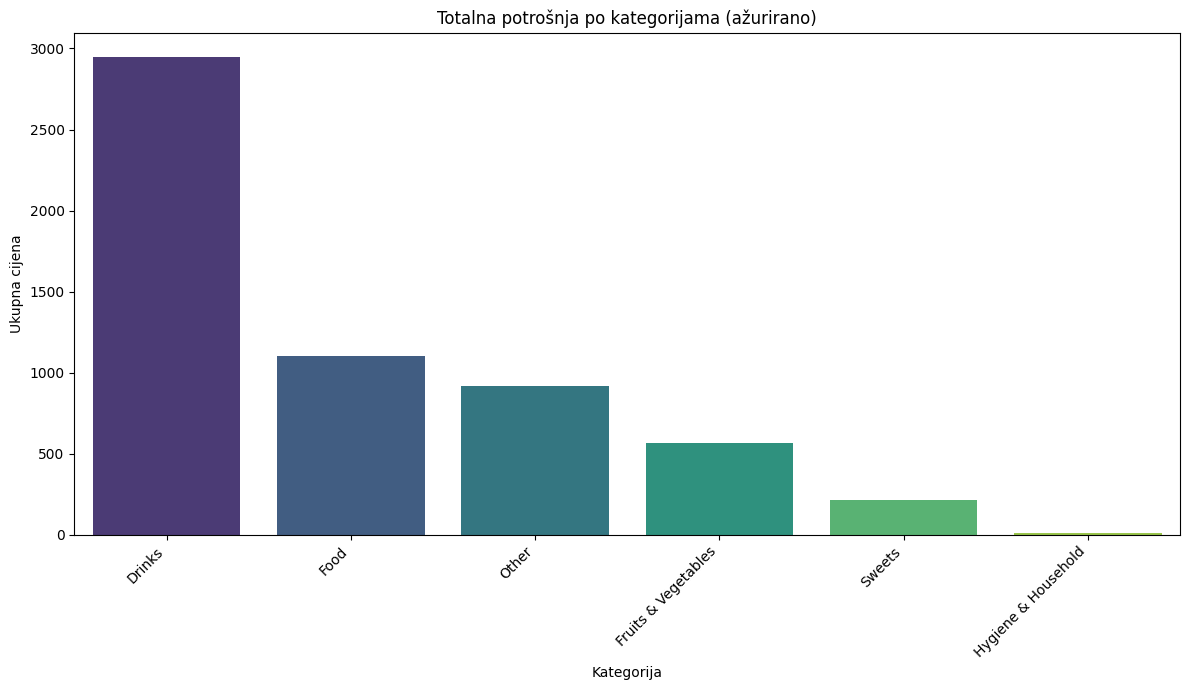

In [ ]:
category_expenses = df.groupby('Category')['Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=category_expenses.index, y=category_expenses.values, palette='viridis')
plt.title('Totalna potrošnja po kategorijama (ažurirano)')
plt.xlabel('Kategorija')
plt.ylabel('Ukupna cijena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("Detaljna tablica potrošnje po kategorijama:")
display(category_expenses.to_frame(name='Ukupna cijena'))

Detaljna tablica potrošnje po kategorijama:


,Ukupna cijena
Category,
Drinks,2948.89
Food,1106.02
Other,921.04
Fruits & Vegetables,569.45
Sweets,216.15
Hygiene & Household,12.00


### Poboljšanje detekcije naziva trgovina

Trenutna detekcija naziva trgovina oslanja se na najčešće riječi iz zaglavlja računa. Da bismo poboljšali točnost, možemo ručno dodati ili ažurirati `STORE_KEYWORDS` rječnik s preciznijim nazivima trgovina ili ključnim riječima koje se često pojavljuju na njihovim računima.

In [ ]:
# Primjer ručnog poboljšanja STORE_KEYWORDS
# Možete dodati specifične nazive trgovina ili prepoznatljive fraze.
# Npr., ako se 'TOTAL' često pojavljuje kao naziv trgovine, ali znamo da to nije prava trgovina,
# možemo ga ukloniti ili dodati specifičnije ključne riječi za stvarne trgovine.

# Trenutni STORE_KEYWORDS
print("Original STORE_KEYWORDS:")
display(STORE_KEYWORDS)

# Primjer dodavanja/ažuriranja specifičnih trgovina
# Npr. ako je 'TOTAL' zapravo 'TOTAL SUPERMARKET'
# ili ako znate da 'ORDER' pripada 'ORDER ONLINE'
STORE_KEYWORDS['TOTAL SUPERMARKET'] = ['total supermarket', 'total market', 'market total']
STORE_KEYWORDS['ORDER ONLINE'] = ['order online', 'online order']
# Možete i ukloniti generičke ključne riječi koje stvaraju zabunu
if 'TOTAL' in STORE_KEYWORDS:
    del STORE_KEYWORDS['TOTAL']
if 'ORDER' in STORE_KEYWORDS:
    del STORE_KEYWORDS['ORDER']

# Ažuriramo i 'detect_store' funkciju kako bi koristila ažurirani rječnik
# Nije potrebna promjena koda funkcije ako je rječnik ažuriran globalno

print("\nAžurirani STORE_KEYWORDS:")
display(STORE_KEYWORDS)

# Nakon ažuriranja, morali bismo ponovno pokrenuti 'PASS 2' za primjenu promjena na rezultatima.

Original STORE_KEYWORDS:


{'ORDER': ['order'],
 'RESTAURANT': ['restaurant'],
 'BLVD': ['blvd'],
 'AVE': ['ave'],
 'TEL': ['tel'],
 'TABLE': ['table'],
 'BAR': ['bar'],
 'JAPANESE': ['japanese'],
 'BELLFLOWER': ['bellflower'],
 'CITY': ['city'],
 'WINGS': ['wings'],
 'TOTAL': ['total'],
 'STREET': ['street'],
 'ARTESIA': ['artesia'],
 'ZOCA': ['zoca'],
 'GARFIELD': ['garfield'],
 'YOUR': ['your'],
 'GUEST': ['guest'],
 'NUMBER': ['number'],
 'BURGER': ['burger'],
 'PHONE': ['phone'],
 'BOWL': ['bowl'],
 'SANTA': ['santa'],
 'CASHIER': ['cashier'],
 'EERE': ['eere'],
 'MIAMI': ['miami'],
 'BEACH': ['beach'],
 'DINE': ['dine'],
 'DINING': ['dining'],
 'MAIN': ['main'],
 'Unknown': []}


Ažurirani STORE_KEYWORDS:


{'RESTAURANT': ['restaurant'],
 'BLVD': ['blvd'],
 'AVE': ['ave'],
 'TEL': ['tel'],
 'TABLE': ['table'],
 'BAR': ['bar'],
 'JAPANESE': ['japanese'],
 'BELLFLOWER': ['bellflower'],
 'CITY': ['city'],
 'WINGS': ['wings'],
 'STREET': ['street'],
 'ARTESIA': ['artesia'],
 'ZOCA': ['zoca'],
 'GARFIELD': ['garfield'],
 'YOUR': ['your'],
 'GUEST': ['guest'],
 'NUMBER': ['number'],
 'BURGER': ['burger'],
 'PHONE': ['phone'],
 'BOWL': ['bowl'],
 'SANTA': ['santa'],
 'CASHIER': ['cashier'],
 'EERE': ['eere'],
 'MIAMI': ['miami'],
 'BEACH': ['beach'],
 'DINE': ['dine'],
 'DINING': ['dining'],
 'MAIN': ['main'],
 'Unknown': [],
 'TOTAL SUPERMARKET': ['total supermarket', 'total market', 'market total'],
 'ORDER ONLINE': ['order online', 'online order']}

In [ ]:
print("Najčešće trgovine u stupcu 'Store':")
display(df['Store'].value_counts())

Najčešće trgovine u stupcu 'Store':


,count
Store,
ORDER,67
TABLE,39
TOTAL,36
AVE,29
RESTAURANT,25
BLVD,9
TEL,5
YOUR,5
BAR,4


### Dodatne vizualizacije za analizu potrošnje

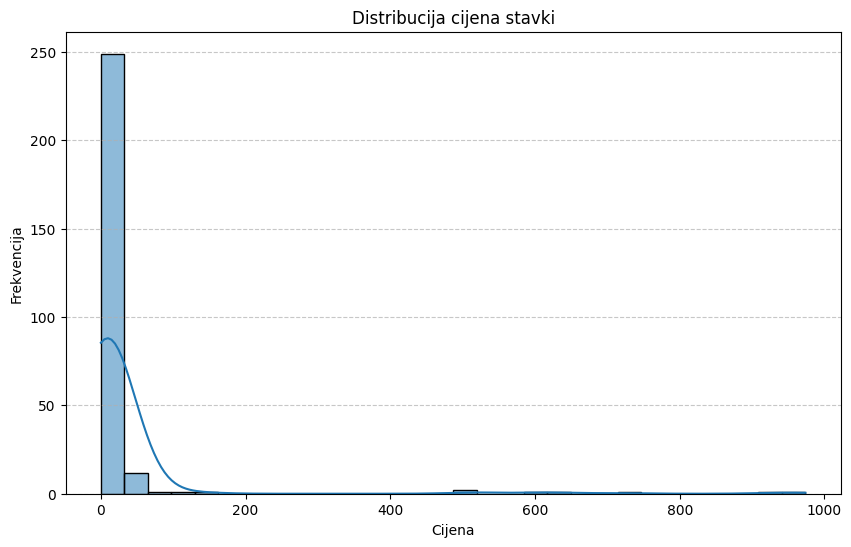

In [ ]:
# Histogram distribucije cijena
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribucija cijena stavki')
plt.xlabel('Cijena')
plt.ylabel('Frekvencija')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_3116/3905400779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_expenses.index, y=store_expenses.values, palette='viridis')


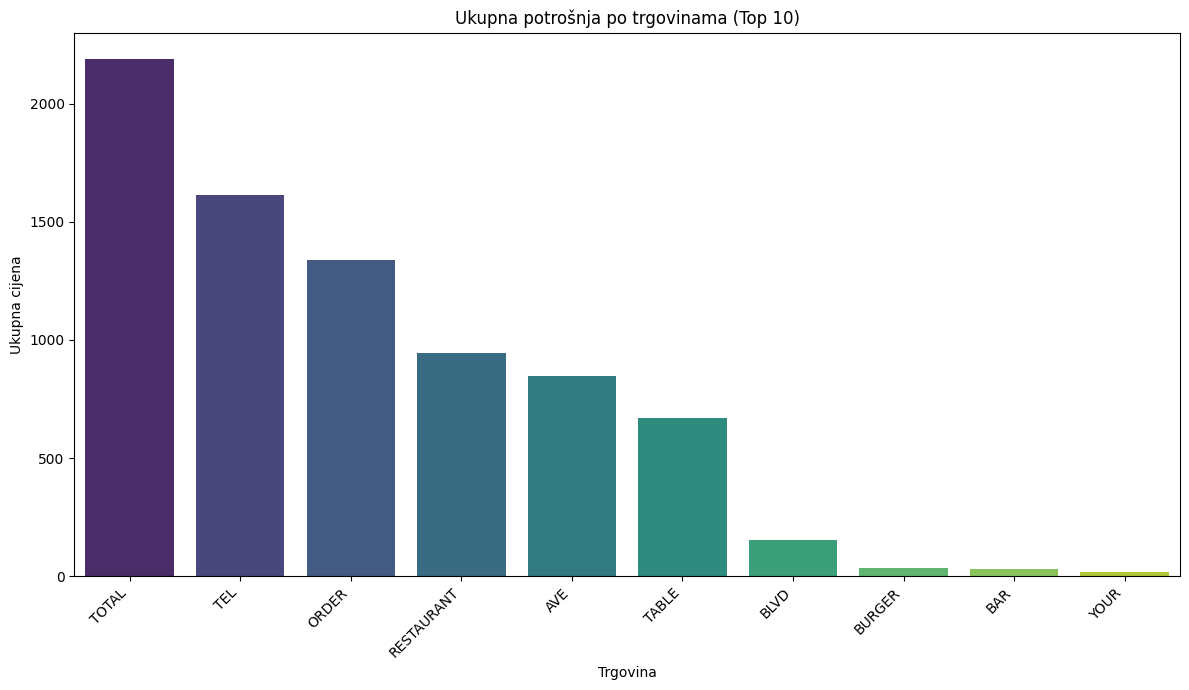

In [ ]:
# Ukupna potrošnja po trgovinama
store_expenses = df.groupby('Store')['Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=store_expenses.index, y=store_expenses.values, palette='viridis')
plt.title('Ukupna potrošnja po trgovinama (Top 10)')
plt.xlabel('Trgovina')
plt.ylabel('Ukupna cijena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3116/2494677277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=currency_expenses.index, y=currency_expenses.values, palette='magma')


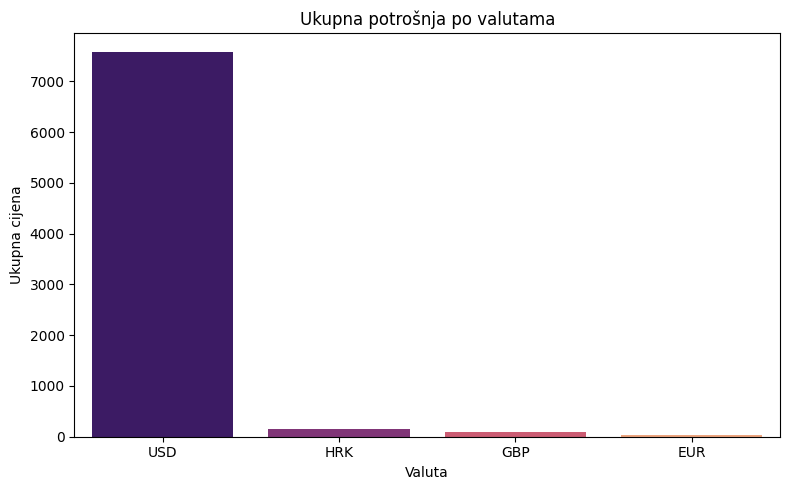

In [ ]:
# Ukupna potrošnja po valutama
currency_expenses = df.groupby('Currency')['Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=currency_expenses.index, y=currency_expenses.values, palette='magma')
plt.title('Ukupna potrošnja po valutama')
plt.xlabel('Valuta')
plt.ylabel('Ukupna cijena')
plt.tight_layout()
plt.show()

In [ ]:
# Filtriranje DataFrame-a da se uklone stavke s cijenom 0.00
df_filtered = df[df['Price'] != 0.00]

print("DataFrame nakon filtriranja cijena 0.00:")
display(df_filtered.head())
print("Novi oblik DataFrame-a:", df_filtered.shape)

DataFrame nakon filtriranja cijena 0.00:


,File,Store,Date,Currency,Category,Original_Item,Price
0,1078-receipt.jpg,ORDER,2026-04-23 16:35:31.336629,USD,Fruits & Vegetables,00% of sale: $,2.33
1,1078-receipt.jpg,ORDER,2026-04-23 16:35:31.336629,USD,Drinks,Ie; $,2.59
3,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Other,2x,0.50
4,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Other,2x,5.00
5,1197-receipt.jpg,BAR,2018-08-28 00:00:00.000000,EUR,Drinks,Hacedon ia,10.00


Novi oblik DataFrame-a: (258, 7)


In [ ]:
top_5_stores = df_filtered.groupby('Store')['Price'].sum().sort_values(ascending=False).head(5)

print("Top 5 trgovina s najvećom potrošnjom (nakon filtriranja 0.00 cijena):")
display(top_5_stores)

Top 5 trgovina s najvećom potrošnjom (nakon filtriranja 0.00 cijena):


,Price
Store,
TOTAL,2191.75
TEL,1612.46
ORDER,1338.80
RESTAURANT,944.12
AVE,845.39


/tmp/ipykernel_3116/1101249214.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_stores.index, y=top_5_stores.values, palette='coolwarm')


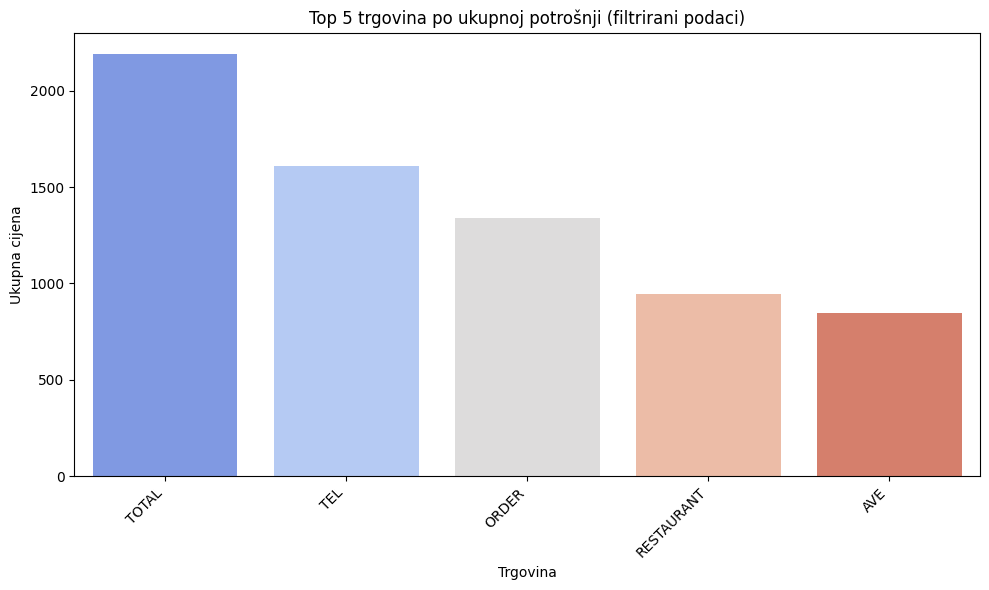

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_stores.index, y=top_5_stores.values, palette='coolwarm')
plt.title('Top 5 trgovina po ukupnoj potrošnji (filtrirani podaci)')
plt.xlabel('Trgovina')
plt.ylabel('Ukupna cijena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

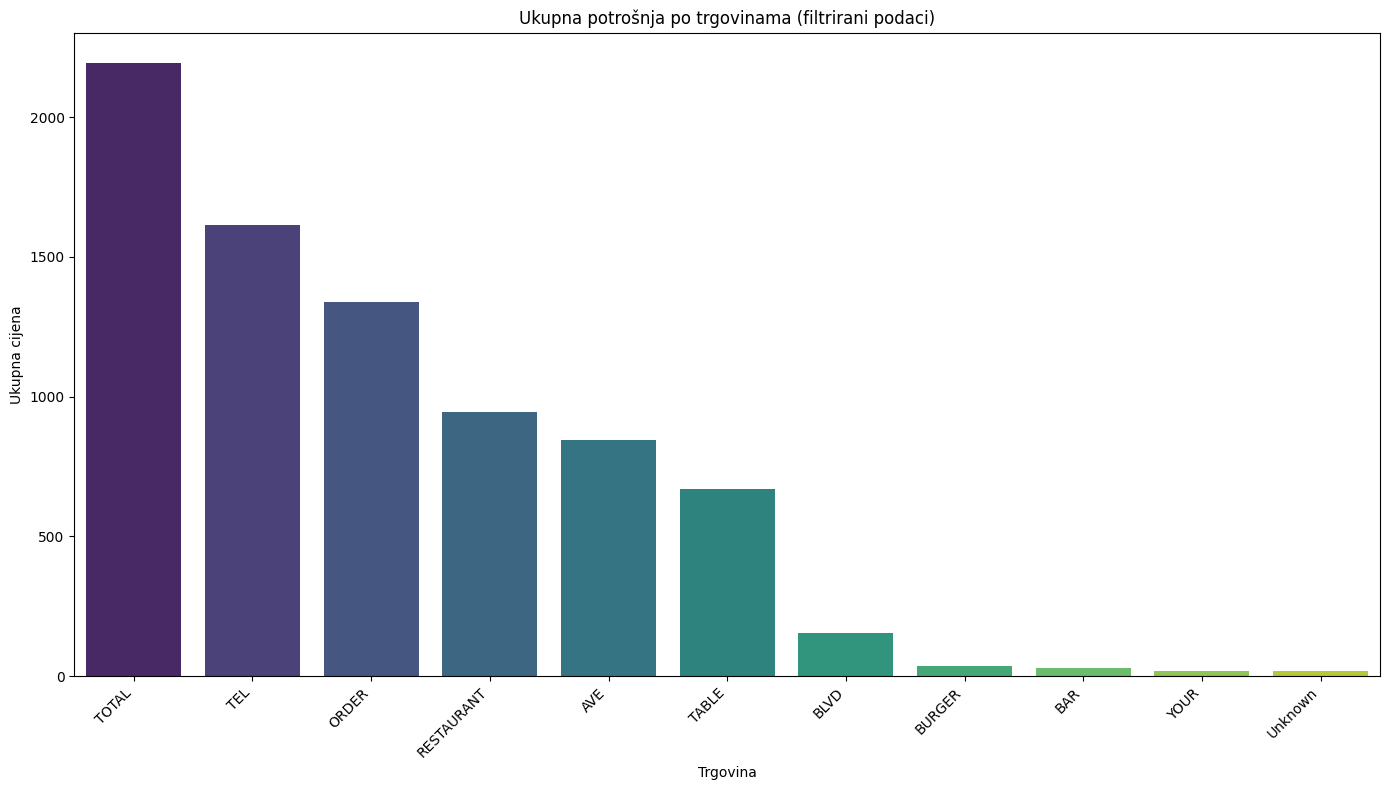

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ukupna potrošnja po trgovinama (ponovno izračunato za sigurnost)
store_expenses_all = df_filtered.groupby('Store')['Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=store_expenses_all.index, y=store_expenses_all.values, hue=store_expenses_all.index, palette='viridis', legend=False)
plt.title('Ukupna potrošnja po trgovinama (filtrirani podaci)')
plt.xlabel('Trgovina')
plt.ylabel('Ukupna cijena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 stavki s najvišom cijenom:")
display(df.sort_values(by='Price', ascending=False).head(10))

Top 10 stavki s najvišom cijenom:


,File,Store,Date,Currency,Category,Original_Item,Price
18,1106-receipt.jpg,TEL,2026-04-23 17:25:51.869060,USD,Drinks,Tel :,973.77
204,1052-receipt.jpg,RESTAURANT,2026-04-23 17:25:51.869060,USD,Drinks,Tel:,718.34
99,1170-receipt.jpg,TABLE,2026-04-23 17:25:51.869060,USD,Food,Chianti (2,614.00
19,1106-receipt.jpg,TEL,2026-04-23 17:25:51.869060,USD,Drinks,c Soy V.,518.95
333,1016-receipt.jpg,AVE,2026-04-23 17:25:51.869060,USD,Other,Ts Fax :,516.77
217,1037-receipt.jpg,YOUR,2026-04-23 17:25:51.869060,HRK,Other,1 PARTY PK 18-22,139.00
248,1162-receipt.jpg,Unknown,2026-04-23 17:25:51.869060,USD,Fruits & Vegetables,4 BT TURNBULL NAPA,90.00
237,1042-receipt.jpg,GUEST,2026-04-23 17:25:51.869060,USD,Other,Amt Due: $,55.39
188,1049-receipt.jpg,TABLE,2026-04-23 17:25:51.869060,USD,Sweets,Snow Combo $,54.00
66,1187-receipt.jpg,DINE,2026-04-23 17:25:51.869060,USD,Sweets,ratale ee,50.38


In [ ]:
# Provjera je li 'Date' stupac već datetime tipa, inače ga pretvori
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filtriranje redaka gdje je datum uspješno konvertiran (uklanjanje NaT vrijednosti)
df_monthly = df.dropna(subset=['Date'])

# Izvuci mjesec iz datuma
df_monthly['Month'] = df_monthly['Date'].dt.to_period('M')

# Izračunaj ukupnu potrošnju po mjesecima
monthly_expenses = df_monthly.groupby('Month')['Price'].sum().sort_values(ascending=False)

print("Ukupna potrošnja po mjesecima:")
display(monthly_expenses)

Ukupna potrošnja po mjesecima:


,Price
Month,
2026-04,5750.55
2018-08,23.00


In [ ]:
output_excel_path = "/content/Expense_Analysis_Final_SRD.xlsx"
df.to_excel(output_excel_path, index=False)
print(f"\n✅ Podaci su uspješno izvezeni u Excel datoteku: {output_excel_path}")


✅ Podaci su uspješno izvezeni u Excel datoteku: /content/Expense_Analysis_Final_SRD.xlsx
